# This notebook demonstrates the use of bi-cross-validation to select number of dimensions using a center-out reaching dataset

Data are trial-averaged firing rates of individual neurons collected from motor cortex (primary motor and dorsal premotor) of a non-human primate.

For this task, the monkey began each trial by touching a central touch-point. A peripheral target was shown, and after a variable, unpredictable delay period, a go cue was delivered. After capturing the peripheral target, the monkey recieved a juice reward, and returned his hand to the touch-point to begin the next trial (see [Lara et al., 2018](https://pubmed.ncbi.nlm.nih.gov/30132759/))

Data have been aligned to target onset, outward movement onset, and return reach onset.

'data' is a Condition x Neuron x Time tensor of trial-averaged firing rates.


## Import various packages

In [1]:
import numpy as np
from scipy import io
import matplotlib.pyplot as plt
from sca.util import get_sample_weights
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sca.models import WeightedPCA

## Helper functions

In [2]:
# Functions to compute SSEs and R2
def get_sses_pred(y_test,y_test_pred):
    sse=np.sum((y_test_pred-y_test)**2,axis=0)
    return sse
def get_sses_mean(y_test):
    y_mean=np.mean(y_test,axis=0)
    sse_mean=np.sum((y_test-y_mean)**2,axis=0)
    return sse_mean
def r2_norm(y,y_pred):
    return 1-np.sum((y-y_pred)**2)/np.sum((y-np.mean(y))**2)

In [3]:
def run_bicv_pca(
    data_time_by_neuron: np.ndarray,
    condition_lengths: np.ndarray,
    latent_dims: np.ndarray,
    n_neuron_folds: int,
    n_condition_folds: int,
    WeightedPCA,
    sample_weights: np.ndarray,
    n_bootstrap: int = 100,
    seed: int = 0,
):
    """
    Bi-cross-validation over neurons and conditions for PCA+linear readout
    
    Parameters
    ----------
    data_time_by_neuron : array, shape (n_timepoints, n_neurons)
        Concatenated data across all conditions along time.
    condition_lengths : array, shape (n_conditions,)
        Number of time bins for each condition. Must sum to n_timepoints.
    latent_dims : array-like, shape (n_latent_settings,)
        List of latent dimensionalities (k values) to evaluate.
    n_neuron_folds : int
        Number of neuron folds (split over neurons).
    n_condition_folds : int
        Number of condition folds (split over conditions).
    WeightedPCA : class
        WeightedPCA implementation (support fit_transform).
    sample_weights : array, shape (n_timepoints, 1)
        Weights for each timepoint when fitting PCA
    n_bootstrap : int
        Number of bootstrap resamples for error bars.
    seed : int
        Random seed.

    Returns
    -------
    pca_multivar_r2_by_latent_dim : array, shape (len(latent_dims),)
        Multivariate R2 for each latent dimensionality.
    pca_multivar_r2_bootstrap : array, shape (len(latent_dims), n_bootstrap)
        Bootstrap distribution for multivariate R2 (for error bars).
    """
    rng = np.random.default_rng(seed)

    condition_lengths = np.asarray(condition_lengths, dtype=int)
    latent_dims = np.asarray(latent_dims, dtype=int)
    n_timepoints, n_neurons = data_time_by_neuron.shape
    n_conditions = condition_lengths.shape[0]

    # ---- Precompute condition time indices ----
    condition_start_idx = np.concatenate(([0], np.cumsum(condition_lengths)[:-1]))
    condition_time_idx = [
        np.arange(condition_start_idx[c], condition_start_idx[c] + condition_lengths[c])
        for c in range(n_conditions)
    ]
    def condition_ids_to_time_indices(condition_ids):
        return np.concatenate([condition_time_idx[c] for c in condition_ids])


    # ---- allocate outputs ----
    n_latent_settings = len(latent_dims)
    pca_predictions_time_by_neuron = np.zeros((n_latent_settings, n_timepoints, n_neurons))
    pca_multivar_r2_by_latent_dim = np.zeros(n_latent_settings)
    pca_multivar_r2_bootstrap = np.zeros((n_latent_settings, n_bootstrap))

    # ---- loops over latent dimension, neuron splits, condition splits ----
    neuron_cv = KFold(n_splits=n_neuron_folds, shuffle=True, random_state=seed)

    for latent_i, n_latent in enumerate(latent_dims):

        for train_neuron_idx, test_neuron_idx in neuron_cv.split(np.arange(n_neurons)):

            # Fit PCA using only training neurons across all timepoints
            pca_model = WeightedPCA(n_components=n_latent)
            pca_latents = pca_model.fit_transform(
                X=data_time_by_neuron[:, train_neuron_idx],
                sample_weight=sample_weights
            ) # shape: (n_timepoints, n_latent)

            # Split by conditions
            condition_cv = KFold(n_splits=n_condition_folds, shuffle=True, random_state=seed)

            for train_condition_idx, test_condition_idx in condition_cv.split(np.arange(n_conditions)):
                train_time_idx = condition_ids_to_time_indices(train_condition_idx)
                test_time_idx = condition_ids_to_time_indices(test_condition_idx)

                # Targets: held-out neurons
                heldout_truth_train_time = data_time_by_neuron[train_time_idx][:, test_neuron_idx]
                heldout_truth_test_time = data_time_by_neuron[test_time_idx][:, test_neuron_idx]

                # Inputs: latents from training neurons
                latent_train_time = pca_latents[train_time_idx, :]
                latent_test_time = pca_latents[test_time_idx, :]

                # Fit linear map from latent -> held-out neurons using training conditions
                linear_model = LinearRegression()
                linear_model.fit(latent_train_time, heldout_truth_train_time)

                # Predict held-out neurons on held-out conditions
                heldout_pred_test_time = linear_model.predict(latent_test_time)

                # Save predictions back into global (time, neuron) alignment
                pca_predictions_time_by_neuron[latent_i, test_time_idx[:, None], test_neuron_idx[None, :]] = (
                    heldout_pred_test_time
                )

        # ---- Multivariate R2 over all neurons/time ----
        sses_pred = get_sses_pred(
            data_time_by_neuron,
            pca_predictions_time_by_neuron[latent_i, :, :]
        )
        sses_mean = get_sses_mean(data_time_by_neuron)
        pca_multivar_r2_by_latent_dim[latent_i] = 1 - np.sum(sses_pred) / np.sum(sses_mean)

        # ---- Bootstrap error bars ----
        for b in range(n_bootstrap):
            bootstrap_neuron_idx = rng.choice(n_neurons, size=n_neurons, replace=True)

            bootstrap_truth = data_time_by_neuron[:, bootstrap_neuron_idx]
            bootstrap_pred = pca_predictions_time_by_neuron[latent_i, :, :][:, bootstrap_neuron_idx]

            sses_mean_b = get_sses_mean(bootstrap_truth)
            sses_pred_b = get_sses_pred(bootstrap_truth, bootstrap_pred)

            pca_multivar_r2_bootstrap[latent_i, b] = 1 - np.sum(sses_pred_b) / np.sum(sses_mean_b)

    return (
        pca_multivar_r2_by_latent_dim,
        pca_multivar_r2_bootstrap,
        )        


## local path to the directory
    - fill in the path to whererever you've saved 'datasets'

In [ ]:
# local_path = ## FILL IN PATH ##
local_path = '../datasets/'

## load & preprocess data 

 ***
 Our data has an innate shape as C x N x T tensor, however we don't require conditions to have same length. 
 For variable condition length, modify `lengths`
 ***

We're going to perform two standard (to this dataset) pre-processing steps:

   1. soft-normalize the rates (firing rate range across all conditions and times + 5)
        This step has the effect of preventing the recovered factors from being dominated by a few high firing-rate neurons while also minimizing the impact of very low firing rate neurons

   2. subtract off the cross-condition mean
        The largest signal (in terms of variance) in motor cortex during reaching is a condition-invariant 'trigger signal' (see [Kaufman et al., 2016](https://pubmed.ncbi.nlm.nih.gov/27761519/) for further discussion).
        Because we are often more interested in the condition-specific signals, we typically subtract off this trigger signal.


In [5]:
data=io.loadmat(local_path + 'monkeyB_reaching.mat')
# pull out the PSTHs
# data is a C x N x T tensor 
data_array=data['data']

#Downsample data to speed up (using a factor of 10 here)
data_downsamp=data_array[:,:,np.arange(0,data_array.shape[2],10)]

# pull out some useful numbers
numConds,numN,trlDur = np.shape(data_downsamp)
print(f"Data shape: {data_downsamp.shape} (conditions x neurons x timepoints)")

Data shape: (8, 124, 301) (conditions x neurons x timepoints)


In [6]:
#Concatenate all the conditions (so the matrix is size N x TC instead of C x N x T)
data_concat=data_downsamp.swapaxes(0,1).reshape([data_downsamp.shape[1],data_downsamp.shape[0]*data_downsamp.shape[2]])

#fr range
fr_range=np.ptp(data_concat,axis=1)[:,None]

#Subtract cross-condition mean
data_scm=data_downsamp-np.mean(data_downsamp,axis=0)[None,:,:]

#Concatenate all the conditions (so the matrix is size N x TC instead of C x N x T)
data_scm_concat=data_scm.swapaxes(0,1).reshape([data_scm.shape[1],data_scm.shape[0]*data_scm.shape[2]])

#Soft normalize (divide each neuron by its fr range + 5)
data_scm_norm=data_scm_concat/(fr_range+5)

# rename the data for convenience
#Note that model requires (T x N) input rather than (N x T), which is why there are transposes below
fit_data=np.copy(data_scm_norm.T)
print(f"Fitting data shape: {fit_data.shape} (timepoints x neurons)")

Fitting data shape: (2408, 124) (timepoints x neurons)


## determine lengths of trials

In [7]:
# --- MODIFY AS NEEDED ---
# NOTE: current concat assumes equal-length conditions; can override 'lengths' for variable-length conditions
# i.e, lengths = np.array([301, 280, 310, ...], dtype=int)
lengths = np.full(numConds, trlDur, dtype=int)
print(f"Using lengths: {lengths}")

# Basic sanity checks
assert lengths.shape == (numConds,)
assert np.all(lengths > 0) and np.all(lengths <= trlDur)
assert np.sum(lengths) == fit_data.shape[0], \
    "Sum of condition lengths must equal total number of timepoints in fit_data"

Using lengths: [301 301 301 301 301 301 301 301]


## User options for bi-cross-validation

In [8]:
Y=np.copy(fit_data) #copy neural data

# how much to weight each timestep (used by)
# 1) weights are inversely related to the norm of the activity across all neurons
sample_weights=get_sample_weights(Y) 
# 2) can also use uniform weights
# sample_weights = np.ones(Y.shape[0])[:, None]

# R_est to loop across, here we pick 1 - 10 with increments of 1, then 10 - 50 with increments of 5
ks= np.append(list(range(1, 10, 1)),list((range(10, 51, 5)))) 
print('Number of dimensions:', ks)

# Cross-validation parameters (modify these as needed)
num_neuron_folds = 10   # 10-fold cross-validation across neurons 
num_condition_folds = 8 # 8-fold cross-validation across conditions (should be a factor of numConds)

Number of dimensions: [ 1  2  3  4  5  6  7  8  9 10 15 20 25 30 35 40 45 50]


In [9]:
# Run BiCV PCA
pca_multivar_r2, pca_multivar_r2_bootstrap = run_bicv_pca(
    data_time_by_neuron=Y,
    condition_lengths=lengths,
    latent_dims=ks,
    n_neuron_folds=num_neuron_folds,
    n_condition_folds=num_condition_folds,
    WeightedPCA=WeightedPCA,
    sample_weights=sample_weights,
    n_bootstrap=100,
    seed=0,
)

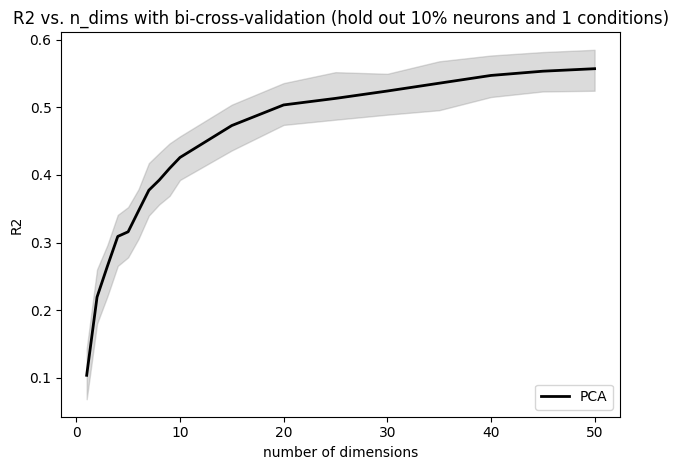

In [10]:
plt.plot(ks, pca_multivar_r2, color='k', label="PCA", linewidth=2, zorder=3)
plt.fill_between(
    ks,
    np.mean(pca_multivar_r2_bootstrap, axis=1) - np.std(pca_multivar_r2_bootstrap, axis=1),
    np.mean(pca_multivar_r2_bootstrap, axis=1) + np.std(pca_multivar_r2_bootstrap, axis=1),
    color='#888888', alpha=0.3
)
plt.legend(loc='lower right')
plt.xlabel('number of dimensions')
plt.ylabel('R2')
plt.title(
    f"R2 vs. n_dims with bi-cross-validation "
    f"(hold out {100/num_neuron_folds:.0f}% neurons and "
    f"{int(len(lengths)/num_condition_folds)} conditions)"
)
plt.tight_layout()
plt.show()

Rule of thumb: number of dimensions can be picked based on the elbow of curve, where the R² value stops increasing significantly